In [4]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
import palava
import os
#import statsmodels.api as sm

import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib
from scipy.ndimage import median_filter
from sklearn.decomposition import PCA
from sklearn.neighbors import kneighbors_graph
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

import igraph as ig

/data/gpfs/projects/punim0614/sandeep_sk/Python_HPC/anaconda3/envs/palava-new2-env/lib/python3.10/site-packages/palava/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/data/gpfs/projects/punim0614/sandeep_sk/Python_HPC/anaconda3/envs/palava-new2-env/lib/python3.10/site-packages/palava/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (


In [5]:

def pathways_with(markers):    
    result = analysis.identifiers(ids=markers,page_size='-1', page='-1',p_value =1)
    token = result['summary']['token']
    str_ = markers + ' \n '
    for path_n in [path['name'] for path in result['pathways']]:
        str_ +='    ' + path_n + ' \n '
    return str_ 


# Helper functions for the plots
def sort_based_on_first_row(matrix):
    sorted_indices = np.argsort(-matrix[0])
    # Rearrange the columns based on the sorted indices
    sorted_matrix = matrix[:, sorted_indices]
    return  sorted_matrix


def plot_gene_expression_boxplot(adata, gene_symbol, order = None, cell_labels = 'cell.labels'):
    # Check if the gene symbol is in adata.var.index
    if gene_symbol not in adata.var.index:
        raise ValueError(f"Gene symbol '{gene_symbol}' not found in adata.var.index.")
    
    # Extract gene expression data for the specified gene
    gene_expression = adata[:, gene_symbol].X
    
    # Ensure that gene_expression is a 1D array
    if gene_expression.ndim > 1:
        gene_expression = gene_expression.toarray().flatten()  # For sparse matrices
    
    # Create a DataFrame with expression data and corresponding cell labels
    df = pd.DataFrame({
        'Gene Expression': gene_expression,
        'Cell Label': adata.obs[cell_labels]
    })
    if order is None:
        order = list(set(adata.obs[cell_labels].values))
    
    # Plot the boxplot using seaborn
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Cell Label', y='Gene Expression', data=df, order=order)
    plt.title(f'Gene Expression Boxplot for {gene_symbol}')
    plt.xticks(rotation=90)
    plt.show()
    plt.close()

def plot_pca(adata, color_by='cell.labels', n_pcs=2):
    """
    This function computes and plots a PCA scatter plot from an AnnData object.
    
    Parameters:
    - adata: AnnData object
    - color_by: Column name in adata.obs to color the plot by (default: 'cell.labels')
    - n_pcs: Number of principal components to compute (default: 2)
    """
    # Check if PCA has already been computed, if not, compute PCA
    if 'X_pca' not in adata.obsm:
        sc.tl.pca(adata, n_comps=n_pcs)
    
    # Create the PCA plot, colored by the specified observation (e.g., cell labels)
    sc.pl.pca(adata, color=color_by, components=[1, 2], title="PCA Plot")


def scatter_plot_grid(data, dim_pairs, ncols=3, label_array=None, palette='tab20', point_size=5.0, title=None):
    """
    Creates a grid of scatter plots based on dimension pairs with a legend for discrete labels.

    Parameters:
        data (np.ndarray): NumPy array with dimensions (dimensions, samples).
        dim_pairs (list of str): List of dimension pairs as strings, e.g., ['1,2', '8,6'].
        ncols (int): Number of columns in the grid.
        label_array (np.ndarray or None): Discrete labels for samples (length must match samples in data).
        palette (str): Color palette for the labels.
        point_size (float): Size of the points in the scatter plots.
        title (str): Title for the grid of scatter plots.
    """
    # Parse dimension pairs into a list of tuples
    dim_pairs = [tuple(map(int, pair.split(','))) for pair in dim_pairs]
    nplots = len(dim_pairs)
    nrows = int(np.ceil(nplots / ncols))  # Determine the number of rows

    # Create a grid of subplots
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3.5))
    axes = axes.flatten()  # Flatten axes array for easier indexing

    for idx, (x_dim, y_dim) in enumerate(dim_pairs):
        ax = axes[idx]

        # Scatter plot for each pair of dimensions
        scatter_df = pd.DataFrame({
            f"Dimension {x_dim}": data[x_dim, :],
            f"Dimension {y_dim}": data[y_dim, :],
            "Label": label_array if label_array is not None else None
        })

        sns.scatterplot(
            data=scatter_df,
            x=f"Dimension {x_dim}",
            y=f"Dimension {y_dim}",
            hue="Label" if label_array is not None else None,
            palette=palette,
            s=point_size,
            ax=ax
        )
        x_label = axis_names_dict.get(x_dim, f"Dimension {x_dim}") if axis_names_dict else f"Dimension {x_dim}"
        y_label = axis_names_dict.get(y_dim, f"Dimension {y_dim}") if axis_names_dict else f"Dimension {y_dim}"
        ax.set_xlabel(x_label, fontsize  =15)
        ax.set_ylabel(y_label, fontsize  =15)
       
        if label_array is not None:
            ax.legend_.remove()  # Remove legend from individual plots

    # Turn off unused axes
    for idx in range(len(dim_pairs), len(axes)):
        axes[idx].axis('off')

    # Add a title
    if title:
        fig.suptitle(title, y=1.02, fontsize=16)

    # Add a custom legend
    if label_array is not None:
        unique_labels = np.unique(label_array)
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='lower center', ncol=len(unique_labels)/2,  fontsize  =11, markerscale =3.5, bbox_to_anchor=(0.5, -0.2))

    plt.tight_layout()
    plt.show()
    

In [6]:
adata_cc_info=sc.read('data/mouse_pancrease_with_cc_info.h5ad')

In [7]:
adata_cc_info

AnnData object with n_obs × n_vars = 3559 × 9140
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'n_gene_s', 'n_gene_u', 'n_counts_s', 'n_counts_u', 'percent_mito_s', 'percent_mito_u', 'DoubletScore', 'cell_type', 'phase', 'G1.score', 'S.score', 'G2M.score', 'velocity_self_transition', 'velocity_u_self_transition', 'velocity_length', 'velocity_confidence', 'velocity_confidence_transition', 'cc', 'top2a', 'smc4', 'pct0', 'cyclone', 'SeuratCC', 'CCStage', 'tricyclePosition'
    var: 'highly_variable_genes', 'fit_r2', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_scaling', 'fit_std_u', 'fit_std_s', 'fit_likelihood', 'fit_u0', 'fit_s0', 'fit_pval_steady', 'fit_steady_u', 'fit_steady_s', 'fit_variance', 'fit_alignment_scaling', 'velocity_genes'
    uns: 'X_name', 'clusters_coarse_colors', 'clusters_colors', 'cyclone', 'emb.m', 'peco', 'reCAT', 'revelio', 'velocity_graph', 'velocity_graph_neg', 'velocity_params', 'velocity_u_graph', 'velocity_u_graph_neg', 'velocity_u_

In [8]:

adata = sc.read('data/mouse_pancreas_updated_beta_with_pdx1.h5ad') 
pathways = [torch.tensor(i) for i in adata.uns['pathways_5000hvg']]

adata.X= adata.X.todense()
adata.X= np.array(adata.X)

In [9]:
num_unann = int(40)

pathway_names = adata.uns['pathway_names']
num_ann = pathway_names.shape[0]
pathway_names_plot = [pathway_names[i].replace('_', ' ' ).capitalize() + ' ['+str(i)+']'  for i in range(len(pathway_names))] + ['Unannotated factor '+ str(i + 1) + ' ['+str(i+num_ann)+']'  for i in range(num_unann)]



In [10]:
cluster_counts = adata.obs['clusters_fine'].value_counts()
print(cluster_counts)

clusters_fine
Ductal           916
Ngn3 high EP     642
Fev+ Beta        452
Beta             308
Pre-Beta         283
Alpha            263
Ngn3 low EP      262
Pre-Alpha        218
Epsilon          142
Delta             70
Fev+ Delta        51
Fev+ Epsilon      46
Fev+ Pyy          32
Fev+ Alpha         6
Pre-endocrine      5
Name: count, dtype: int64


In [11]:
gene_names = adata.var
num_genes = len(adata.var)

pathways_bool = pathways
path_uann =  torch.zeros(num_genes)

pathways_bool += [path_uann] * num_unann


In [12]:
SCVI_palava = palava.model.SCVI_palava
SCVI_palava.setup_anndata(adata, layer = 'counts')

/data/gpfs/projects/punim0614/sandeep_sk/Python_HPC/anaconda3/envs/palava-new2-env/lib/python3.10/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)


In [15]:

#dr = 'Out_files_and_results/mouse_pancreas_2k/small_lr_seed=3_lambda=0.5_lambda_marker_genes=0.1_palava_width=25_list_of_nonlin_factors=8-26-50-51'
dr = 'saved_models/small_lr_seed=3_lambda=0.5_lambda_marker_genes=0.1_palava_width=25_list_of_nonlin_factors=8-26-50-51'


In [16]:
scvi_palava = SCVI_palava.load(dr+'/latent_and_slope_data/scvi_model', adata)


Number of latent variables = 94: 54 annotated + 40 unannotated


In [17]:
scvi_palava

PALAVA in SCVI framework with the following params: 
n_hidden: 128, lambda: [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 
0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 
0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.1, 0.1, 0.1, 0.1, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 
0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 
0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25], palava_n_hidden: 25 n_latent: 94, 
n_layers: 3, dropout_rate: 0.1, dispersion: gene, gene_likelihood: zinb, latent_distribution: normal
Training status: Trained
Model's adata is minified?: False

for i in [0, 1, 3]:
    dr =  f'Out_files_and_results/mouse_pancreas_2k/small_lr_seed={i}_lambda=0.5_lambda_marker_genes=0.1_palava_width=25_list_of_nonlin_factors=8-26-50-51'
    scvi_palava = SCVI_palava.load(file = dr+'/latent_and_slope_data/scvi_model', adata = adata)
    print(i, scvi_palava.history['elbo_train'].iloc[[849]])

In [19]:


med_libsize = np.median(np.sum(adata.X, axis = 1))
print("Median library size is " + str(med_libsize))
adata_norm = sc.pp.normalize_per_cell(adata, counts_per_cell_after = med_libsize, copy = True)
adata_norm = sc.pp.log1p(adata_norm, copy = True)

sc.tl.pca(adata_norm, n_comps=50)
adata_norm.obs =adata_norm.obs.merge(adata_cc_info.obs, how='left', left_index=True, right_index=True)
adata_norm

Median library size is 1180.0


AnnData object with n_obs × n_vars = 3696 × 2000
    obs: 'clusters_coarse_x', 'clusters_x', 'S_score_x', 'G2M_score_x', 'in_cr_data', 'clusters_fine', 'day', 'proliferation', 'phase_x', 'louvain_Alpha', 'louvain_Beta', 'palantir_pseudotime', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'macrostates_fwd', 'term_states_fwd', 'term_states_fwd_probs', 'clusters_gradients', 'cr_prob_fate_Alpha', 'cr_prob_fate_Beta', 'cr_prob_fate_Epsilon', 'cr_prob_fate_Delta', '_scvi_batch', '_scvi_labels', 'clusters_coarse_y', 'clusters_y', 'S_score_y', 'G2M_score_y', 'n_gene_s', 'n_gene_u', 'n_counts_s', 'n_counts_u', 'percent_mito_s', 'percent_mito_u', 'DoubletScore', 'cell_type', 'phase_y', 'G1.score', 'S.score', 'G2M.score', 'velocity_self_transition', 'velocity_u_self_transition', 'velocity_length', 'velocity_confidence', 'velocity_confidence_transition', 'cc', 'top2a', 'smc4', 'pct0', 'cyclone', 'SeuratCC', 'CCStage', 'tricyclePosition'
    var: 'highly_variable_gen

In [20]:
adata.obsm["X_scVI"] = scvi_palava.get_latent_representation()

/data/gpfs/projects/punim0614/sandeep_sk/Python_HPC/anaconda3/envs/palava-new2-env/lib/python3.10/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)


In [21]:
latent = adata.obsm["X_scVI"][:,:(num_ann + num_unann)]
learned_activations = np.transpose(latent)

In [22]:
ind_sort = np.argsort(adata.obs['clusters_fine'].values)

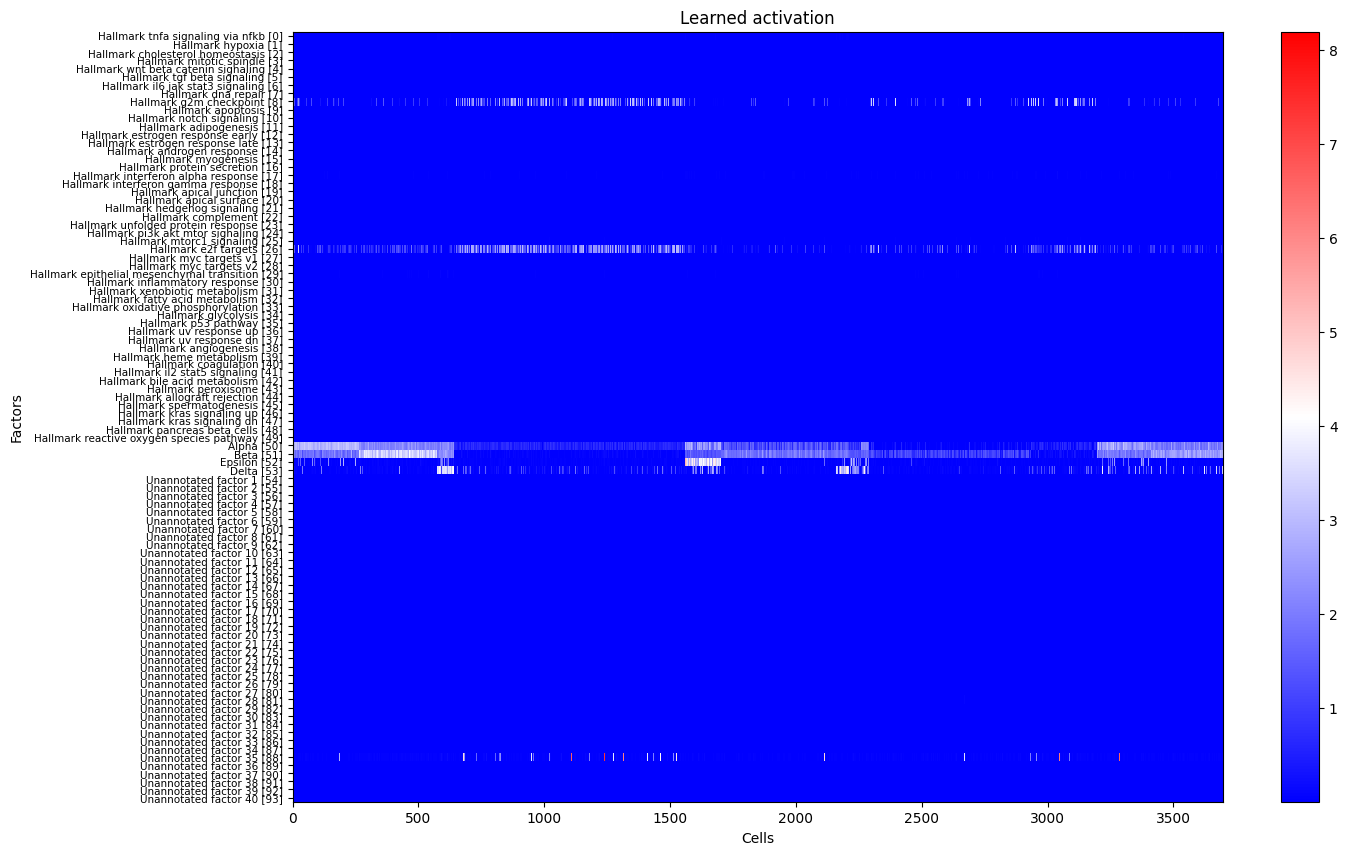

In [23]:

plt.figure(figsize=(15, 10))
plt.imshow(learned_activations[:, ind_sort],   aspect = 'auto', cmap='bwr', interpolation = 'none', rasterized=True)
plt.title("Learned activation")
plt.xlabel('Cells')
plt.ylabel('Factors')
_ = plt.yticks([i for i in range(len(pathway_names_plot))], pathway_names_plot, fontsize = 7.5)
cbar = plt.colorbar()

Text(0, 0.5, 'G2M checkpoint factor')

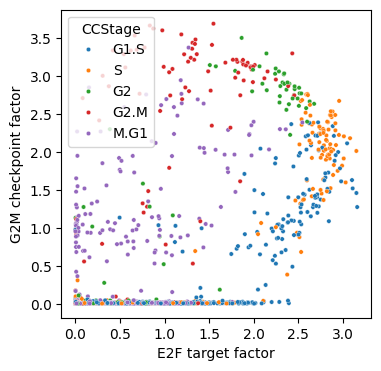

In [24]:
#cycling_palette = {'Non-cycling': '#E4DFDA', 'G2M': '#0d5706', 'S': '#1f2387'}
#cycling_palette.update{'G2.M':, 'G2', 'NA', 'M.G1', 'G1.S'}

obs_column ='cc'

p1, p2 = 'S_score', 'G2M_score'
duct_indx = adata.obs['clusters'] == 'Ductal'


plot_df = pd.DataFrame({
        f'dim_0': learned_activations[8,:].flatten(),
        f'dim_1': learned_activations[26, :].flatten(),
       'CCStage':adata_norm.obs[obs_column],
    'clusters' :adata.obs['clusters']
    })

plot_df = plot_df[plot_df['CCStage'] != 'NA']
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(4 , 4))
ax = axes

sns.scatterplot(data=plot_df, x='dim_1', y='dim_0', s=10, hue='CCStage', ax =ax,rasterized=True)

plt.xlabel('E2F target factor')
plt.ylabel('G2M checkpoint factor')

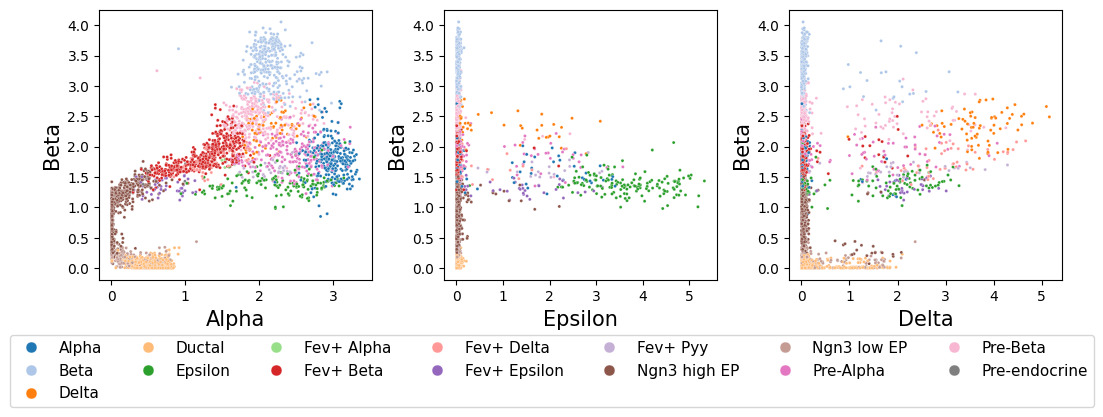

In [30]:
#    continue
adata.obsm["X_scVI"] = scvi_palava.get_latent_representation()
latent = adata.obsm["X_scVI"][:,:(num_ann + num_unann)]
learned_activations = np.transpose(latent)

axis_names_dict = {50: 'Alpha',  51 : 'Beta', 52: 'Epsilon', 53: 'Delta', 8:'G2M checkpoint', 26:'E2F targets'}

scatter_plot_grid(learned_activations, dim_pairs = ["50,51","52,51","53,51"], ncols=3, label_array = adata_norm.obs['clusters_fine'],  palette='tab20', point_size=5.0, title=None)

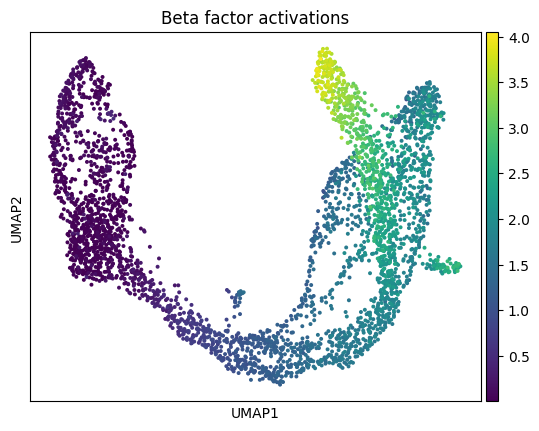

In [31]:
adata_norm.obs['a_factor'] = learned_activations[51, :]
sc.pl.umap(adata_norm, color='a_factor', title = 'Beta factor activations')

[]
Hallmark interferon alpha response [17]
Hallmark mtorc1 signaling [25]
Hallmark tnfa signaling via nfkb [0]
Unannotated factor 35 [88]
Delta [53]
Epsilon [52]
Hallmark e2f targets [26]
Hallmark g2m checkpoint [8]
Alpha [50]
Beta [51]


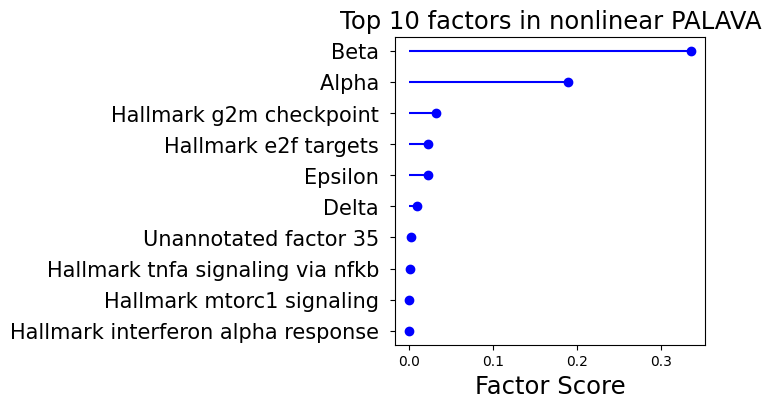

In [32]:
factor_importance_dict  = np.load(dr + '/factor_importance_scores_dict.npy', allow_pickle=True)[()]


factor_importance = factor_importance_dict['factor_importance']

highlighted_pathways =  []


pathway_names_plot = pathway_names_plot
factor_importance =factor_importance

factor_importance_only_ann = factor_importance #[:50]


index_asc_order = np.argsort(factor_importance_only_ann)[::-1][:10][::-1]

print([x for x in highlighted_pathways if x not in np.array(pathway_names_plot)[index_asc_order]])

plt.figure(figsize=(4, 4))
for i, idx in enumerate(index_asc_order):
    pathway_name = pathway_names_plot[idx]
    color = 'b' if pathway_name in highlighted_pathways else 'b'
    print(pathway_name)
    plt.stem([pathway_name.split('[')[0]], [factor_importance_only_ann[idx]], markerfmt=color+'o', linefmt=color+'-', orientation='horizontal')

#  plt.stem(np.array(pathway_names_plot)[index_asc_order], factor_importance[index_asc_order], markerfmt='ro', linefmt='b-', orientation='horizontal')
plt.title('Top 10 factors in nonlinear PALAVA', fontsize =17.5)
plt.xlabel('Factor Score', fontsize =17.5)
plt.tick_params(axis='y', which='major', labelsize=15)
            
red_patch = mpatches.Patch(color='red', label='Kown to be present')
blue_patch = mpatches.Patch(color='blue', label='Not known to be present')

#plt.legend(handles=[red_patch, blue_patch])

plt.show()

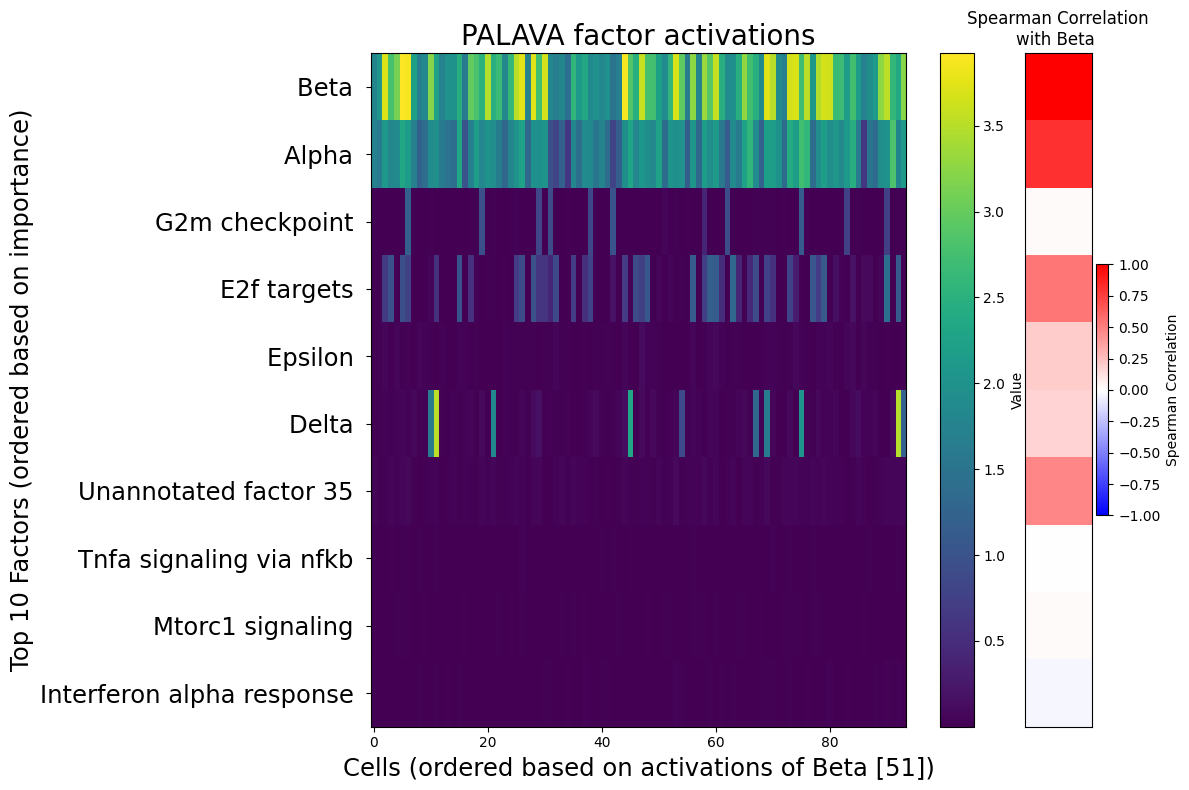

In [33]:
fac = 51
adata.obsm["X_scVI"] = scvi_palava.get_latent_representation()
latent = adata.obsm["X_scVI"][:,:(num_ann + num_unann)]
learned_activations = np.transpose(latent)
alph =['Alpha', 'Pre-Alpha', 'Fev+ Alpha']
beta = ['Beta', 'Pre-Beta', 'Fev+ Beta']
cell_ind = adata.obs['clusters_fine'].isin(beta).values

earned_activations_subset = learned_activations[:,cell_ind]

ind_sort = np.argsort(earned_activations_subset[:,  fac])
ind_sort = ind_sort
n_top = 10
subset_indx = np.argsort(factor_importance)[::-1][:n_top]
data = earned_activations_subset[subset_indx, :]

# Index of the row to compare with
pathway_names_plot_subset = [pathway_names_plot[i] for i in subset_indx]
# Extract the ith row
i = fac # Index of HEME factor 

target_row = earned_activations_subset[i, :]

# Compute Spearman's correlation for each row with the target row
correlations = np.array([spearmanr(target_row, row).correlation for row in data])

# Plot the data matrix and the Spearman correlation side by side, the tied observations receive the same average rank
fig, axes = plt.subplots(1, 2, figsize=(12, 8), gridspec_kw={'width_ratios': [4, 0.5]})

# Plot the data matrix on the left
im = axes[0].imshow(data[:,ind_sort], aspect='auto', cmap='viridis', interpolation='nearest')
axes[0].set_title("PALAVA factor activations", fontsize = 20)
axes[0].set_xlabel("Cells (ordered based on activations of "+pathway_names_plot[fac]+")", fontsize = 17.5)
axes[0].set_ylabel(f"Top {n_top} Factors (ordered based on importance)", fontsize = 17.5)
axes[0].set_yticks([i for i in range(len(pathway_names_plot_subset))], [i.split('[')[0].replace('Hallmark ', '').capitalize() for i in pathway_names_plot_subset], fontsize = 17.5)

plt.colorbar(im, ax=axes[0], label='Value')

# Plot the correlations as a single row on the right
correlation_matrix = correlations.reshape(-1, 1)  # Convert to a column vector for plotting
im_corr = axes[1].imshow(correlation_matrix, aspect='auto', cmap='bwr', interpolation='nearest' ,vmin=-1, vmax=1)
axes[1].set_title(f"Spearman Correlation\nwith " +pathway_names_plot[i].split('[')[0])
axes[1].set_xticks([])  # Remove x-axis ticks for clarity
axes[1].set_yticks([])  # Remove y-axis ticks for clarity
plt.colorbar(im_corr, ax=axes[1], label='Spearman Correlation')

# Adjust layout
plt.tight_layout()
plt.show()


(262,)


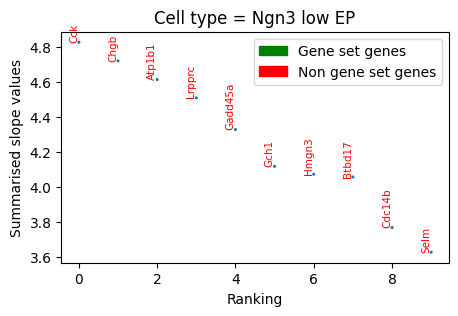

(642,)


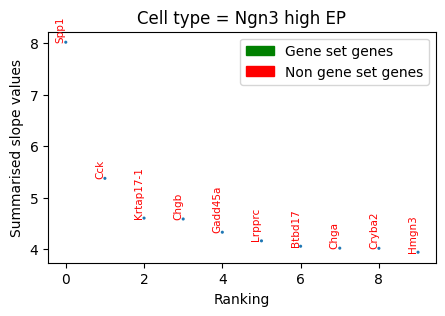

(452,)


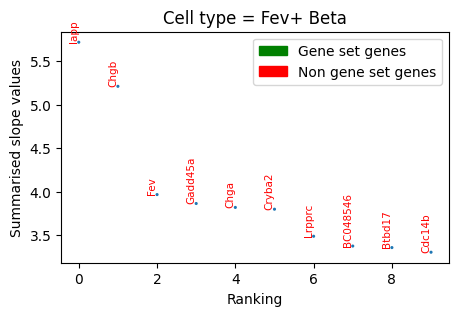

(283,)


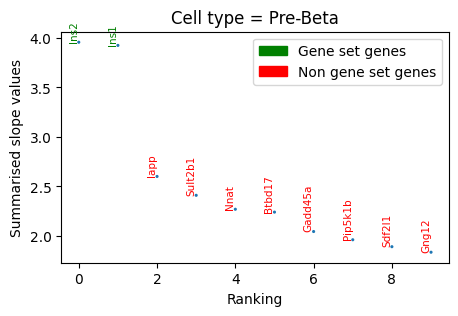

(308,)


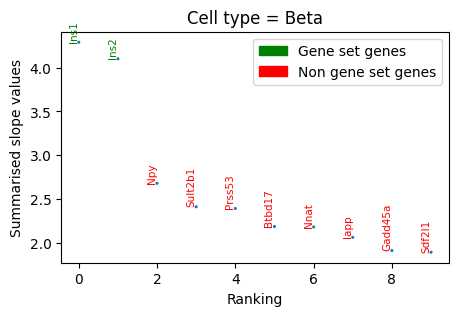

In [34]:


def spline_val(fac):
    x =  torch.tensor(learned_activations) #torch.linspace(0,4,100)[:, None]
    model_ = copy.deepcopy(scvi_palava.module.decoder.px_decoder.annotated_generative_model)
    model_.to_cpu()
    y = model_.pathway_expression(x.T, fac)
    
    return [y.detach().numpy()]


# ['Early Erythroid', 'Late Erythroid', 'MEMP', 'Mid Erythroid']
def median_smooth_rows(arr, window_size=11):
    # Apply median filtering to each row of the array
    smoothed = np.apply_along_axis(lambda x: median_filter(x, size=window_size), axis=0, arr=arr)
    return smoothed

cell_type_genes = {}

def print_list(my_list):
  print("[", ", ".join(f"'{item}'" for item in my_list), "]")

# 53, 64, 26, 58
fac =51



# data_dict = {'data': learned_activations[fac,:],
#             'cell_type': adata.obs['clusters_fine'].values}

# df = pd.DataFrame(data_dict)
# mean_per_cell_type = df.groupby('cell_type')['data'].mean()

# plt.figure(figsize=(10, 6)) 
# df.boxplot(column='data', by='cell_type', grid=False, showfliers=True)
# plt.xticks(rotation = 90)
# plt.show()
# plt.close()

px_dropout_decoder_ = copy.deepcopy(scvi_palava.module.decoder.px_dropout_decoder)

px_dropout_decoder_.cpu()

px_latent = torch.tensor(scvi_palava.get_latent_representation(return_other_latents=True)[:,(num_ann + num_unann):])

posterior_probs = px_dropout_decoder_(px_latent)

drop_out_mask = adata.X != 0 # posterior_probs.detach().numpy()<1e-8



slopes_for_all_fac_lst = scvi_palava.spline_approach(factors = [50, 51])
slopes_for_all_fac_lst =[i * drop_out_mask for i in slopes_for_all_fac_lst]

for cell_type in ['Ngn3 low EP','Ngn3 high EP','Fev+ Beta', 'Pre-Beta', 'Beta']: # ['Fev+ Beta', 'Pre-Beta', 'Beta']
 
    
    cell_type_cell_ind = np.where(np.isin(adata.obs['clusters_fine'].values.to_numpy(),[cell_type]))[0]
    print(cell_type_cell_ind.shape)
    slopes_for_all_fac  = {i:j[cell_type_cell_ind, : ] for i, j  in zip([50, 51],slopes_for_all_fac_lst)}


    if cell_type in  ['Ngn3 low EP','Ngn3 high EP','Fev+ Beta',]:
      #  data_1 = np.quantile(abs(np.concatenate((slopes_for_all_fac[50], slopes_for_all_fac[51]))), q = 0.95, axis = 0)
            data_1 = np.quantile(abs((slopes_for_all_fac[50])), q = 0.95, axis = 0)

            data_1 += np.quantile(abs((slopes_for_all_fac[51])), q = 0.95, axis = 0)

    else:
        data_1 = np.quantile(abs((slopes_for_all_fac[51])), q = 0.95, axis = 0)
        
    #data_1 += np.quantile(abs((slopes_for_all_fac[51])), q = 0.95, axis = 0)

  #  

    #else:
    #    data_1 = np.quantile(abs(slopes_for_all_fac[51]), q = 0.95, axis = 0)
       


    
    data_1_and_de_no_error = np.concatenate((data_1[None], pathways_bool[fac].numpy()[None],gene_names.index.to_numpy()[None]), axis=0)
    data_1_and_de_no_error = sort_based_on_first_row(data_1_and_de_no_error)
    
    n_top_genes = 10
    
    y = data_1_and_de_no_error[0][:n_top_genes]
    x = np.array([i for i in range(n_top_genes)])
    
    plt.figure(figsize=(5, 3))
    plt.scatter(x, y, s = 5, edgecolor='none')
    
    # plotting pathway genes
    pathway_gene_ind = data_1_and_de_no_error[1][:n_top_genes] == 1
    #x_pathway = (data_1_and_de_no_error[1][:n_top_genes] * x)[pathway_gene_ind]
    #y_pathway = (np.ones(n_top_genes) * -0.05)[pathway_gene_ind]
    # plt.scatter(x_pathway, y_pathway, c='black', marker='|', label='In gene set',rasterized=True)
    
    plt.xlabel('Ranking')
    plt.ylabel('Summarised slope values')
    plt.title( 'Cell type = '+ cell_type )
    
    #pdf_pages.savefig(bbox_inches='tight')
    top_gene_names = [element for element in data_1_and_de_no_error[2][:n_top_genes]]
    for i, txt in enumerate(top_gene_names):
         color = ['r', 'g'][int(data_1_and_de_no_error[1][i])]      
         plt.annotate(txt, (x[i], y[i]), ha = 'right', va = 'bottom', rotation = 90, fontsize = 7.5, color = color)
    geneset = mpatches.Patch(color='g', label='Gene set genes')
    nongeneset = mpatches.Patch(color='r', label='Non gene set genes')
    
    plt.legend(handles=[geneset, nongeneset])
    plt.show()
    plt.close()
    count = 0 
    
    order_ = None
    # for i, txt in enumerate([element for element in data_1_and_de_no_error[2][:n_top_genes]]):
    # #if 0 == int(data_1_and_de_no_error[1][i]):
    #         count += 1
    #     #    print('_'*25)
    #     #    print(txt)
    #      #   print(pathways_with(txt))
    #         plot_gene_expression_boxplot(adata_norm, txt, order =order_ )
    #         if count > 5:
    #             break
    index_for_mat_plor = [ np.where(adata.var.index.to_numpy() == data_1_and_de_no_error[2][:n_top_genes][i])[0][0] for i in range(n_top_genes)]
    
   # ind_sort = np.argsort(latent[:,  20])
    
    # subset_for_matplot = adata_norm.X[:,index_for_mat_plor]/ adata_norm.X[:,index_for_mat_plor].max(axis =0)
    # subset_for_matplot = median_smooth_rows(subset_for_matplot[ind_sort,:])
    # plt.imshow(subset_for_matplot.T, aspect ='auto', interpolation ='none')
    # plt.title('Cell type = '+ cell_type +' - Gene expression')
    # plt.xlabel('Cells ordered by Heme factor')
    # plt.colorbar()
    # plt.show()
    # plt.close()

    cell_type_genes[cell_type] = data_1_and_de_no_error[2][:n_top_genes]


    if False:
        matrix = median_smooth_rows( adata_norm.X[:,index_for_mat_plor][ind_sort,:]/adata_norm.X[:,index_for_mat_plor][ind_sort,:].sum(axis =0), window_size=25)   # Example: 100 cells, 2000 genes
        matrix_transposed = matrix.T  # Now the shape is (genes, cells)
        
        # Step 1: Compute the k-nearest neighbors graph using sklearn
        knn_graph = kneighbors_graph(matrix_transposed, n_neighbors=10, mode='connectivity', include_self=False)
        
        # Step 2: Convert the KNN graph to an igraph object
        sources, targets = knn_graph.nonzero()  # Get the source and target node pairs
        edges = list(zip(sources, targets))     # Create edge list
        g = ig.Graph(edges=edges, directed=False)
        
        # Step 3: Perform Louvain clustering using igraph
        louvain_clusters = g.community_multilevel(resolution = 0.15)  # Use Louvain
        gene_clusters = louvain_clusters.membership  # Cluster labels for each gene


        for clus in  set(gene_clusters):
            print('cluster',clus, '-'*20)
            print_list(np.array(top_gene_names)[np.array(gene_clusters)==clus])
        # Step 4: Perform PCA on the transposed matrix (genes as rows)
        pca = PCA(n_components=2)
        pca_result = pca.fit_transform(matrix_transposed)
        
        # Step 5: Plot the PCA results, coloring by cluster labels
        plt.figure(figsize=(8, 6))
        sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=gene_clusters, palette='tab10', s=25)
        plt.title('PCA of Genes Colored by Louvain Clusters')
        plt.xlabel('PCA 1')
        plt.ylabel('PCA 2')
        plt.legend(title='Cluster')
        
        for i, gene_name in enumerate(top_gene_names):
            if gene_name in ['GATA2', 'HBB', 'NOP10','CAST','SYNGR1','SOX4', 'PHOSPHO1', 'CD36', 'AHSP','PHO', 'NFIX', 'IL1B', 'BTG2', 'GAL', 'PLAC8', 'DDAH2', 'TESPA1', 'KRT1', 'TSPO2','CYBA','SRGN']:
                plt.text(pca_result[i, 0], pca_result[i, 1], gene_name, fontsize=9, alpha=0.7, color ='red')
            else:
              # plt.text(pca_result[i, 0], pca_result[i, 1], gene_name, fontsize=5, alpha=1.0, color = 'black')
               pass 
    
        plt.show()
#slopes_for_all_fac_lst[0]

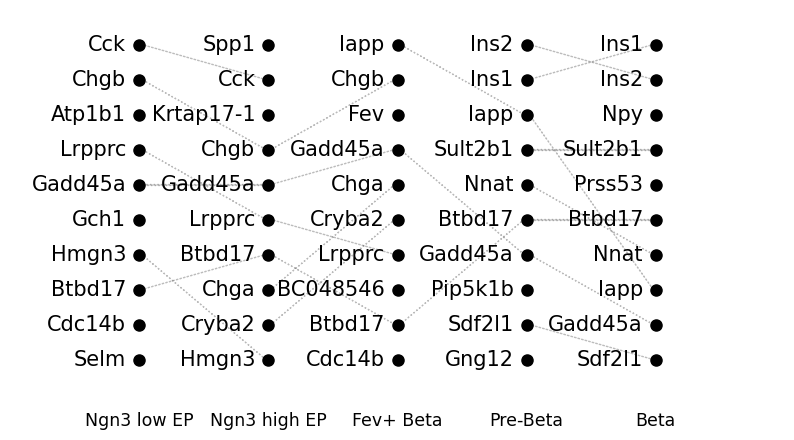

In [36]:



def plot_multiple_ranks(data, colors=None, labels_offset=0.1, arrow_len=0, y_spacing=1, 
                        draw_uncolored_edges=True, title='', show_uncolored_nodes=True, color_legend=None):
    """
    Plots ranked lists with connections and optional coloring and legend.
    
    Parameters:
    - data: dict
        A dictionary where keys are list names and values are ranked lists.
    - colors: dict, optional
        A dictionary mapping items to colors.
    - labels_offset: float, optional
        Horizontal offset for text labels.
    - arrow_len: float, optional
        Arrowhead length for connections.
    - y_spacing: float, optional
        Vertical spacing between nodes.
    - draw_uncolored_edges: bool, optional
        Whether to draw edges for uncolored nodes.
    - title: str, optional
        Title for the plot.
    - show_uncolored_nodes: bool, optional
        Whether to display labels for uncolored nodes.
    - color_legend: dict, optional
        A dictionary mapping colors to legend labels (e.g., {'red': 'Beta', 'green': 'Delta'}).
    """
    import numpy as np  # Import if not already in use
    import matplotlib.patches as mpatches  # For creating legend patches
    
    keys = list(data.keys())  # Extract the keys from the dictionary
    num_lists = len(keys)  # Number of input lists
    fig, ax = plt.subplots(figsize=(10, 5))
    
    ax.set_xlim(0, num_lists + 1)  # Adjust x-limits based on the number of lists
    max_len = max(len(lst) for lst in data.values())  # Find the longest list for y-axis limits
    
    # Reverse the order of each list
    reversed_data = {key: lst[::-1] for key, lst in data.items()}

    # Calculate y-values for each reversed list
    y_values = [np.arange(1, len(reversed_data[key]) * y_spacing + 1, y_spacing) for key in keys]
    ax.set_ylim(0, max(len(lst) * y_spacing for lst in reversed_data.values()) + y_spacing)  # Set y-limits
    
    ax.axis('off')  # Remove axes

    # Draw arrows between the lists
    for i in range(num_lists - 1):  # Loop through each adjacent pair of lists
        current_list = reversed_data[keys[i]]
        next_list = reversed_data[keys[i + 1]]
        
        # Create a mapping from current list to next list
        current_to_next = [next_list.index(item) if item in next_list else None for item in current_list]
        
        for j in range(len(current_list)):
            if current_to_next[j] is not None:
                # Determine the color for the edge based on the current node color
                edge_color = colors.get(current_list[j], 'black') if colors else 'black'
                
                # Check if we should skip drawing this edge
                if edge_color == 'black' and not draw_uncolored_edges:
                    continue
                
                # Draw the arrow with the corresponding edge color
                ax.arrow(i + 1.02, y_values[i][j], 
                         0.96, y_values[i + 1][current_to_next[j]] - y_values[i][j], 
                         head_width=arrow_len, head_length=arrow_len, 
                         fc=edge_color, ec=edge_color, length_includes_head=True, linestyle=':', alpha=0.25)

    # Plot points for each reversed list
    for i, key in enumerate(keys):
        lst = reversed_data[key]
        for j in range(len(lst)):
            # Default to black for the points
            ax.plot(i + 1, y_values[i][j], 'o', markersize=8, color='black')  # Points
            
            # Determine the color for each gene, defaulting to black if not found
            text_color = colors.get(lst[j], 'black') if colors else 'black'
            
            # Show the node name only if the color is specified or if show_uncolored_nodes is True
            if text_color != 'black' or show_uncolored_nodes:
                ax.text(i + 1 - labels_offset, y_values[i][j], lst[j], 
                        verticalalignment='center', horizontalalignment='right', color=text_color, fontsize=15)

        # Add key label at the bottom of each column
        ax.text(i + 1, -0.5, key, verticalalignment='top', horizontalalignment='center', fontsize=12.5)

    # Add title
    plt.title(title, fontsize=20)

    # Add legend if color_legend is provided
    if color_legend:
        legend_patches = [mpatches.Patch(color=color, label=label) for color, label in color_legend.items()]
        ax.legend(handles=legend_patches, loc='lower center', fontsize=15, title="Legend", bbox_to_anchor=(0.7, 0., 0.5, 0.5) )
    
    plt.show()



# Example usage
data = {cell_type:cell_type_genes[cell_type].tolist() for cell_type in cell_type_genes.keys()}
color_genes = {'red':'Mafb'}
color_legend = {}
if False: #beta cells
    # Define colors for specific genes
    color_genes = {
        gene: 'green' for gene in ['Ins2','Ins1', 'Iapp', 'Nnat'] #alpha
    }
    color_genes.update( {
        gene: 'red' for gene in ['Rbp4','Pcsk1n', 'BC048546','Hap1', 'Cryba2', 'Lrpprc', 'Pam', 'Btbd17', 'Gast'] #alpha
    })
    
    color_genes.update( {
        gene: 'blue' for gene in ['Npy', 'Syndig1l'] #alpha
    })
    color_genes.update( {
        gene: 'violet' for gene in ['Mapt', 'Igfbp7', 'G6pc2'] #alpha
    })
    color_genes.update( {
        gene: 'yellow' for gene in ['Mafb'] #alpha
    })
    color_legend = {'green':'Known marker genes',
               'red': 'Genes in the top Fev +Beta cells',
               'Violet': 'Genes in the top Pre-Beta genes',
               'blue': 'Genes in the top Beta genes'}

if False: # Alpha cells 
    color_genes = { 'Ttr':'blue', 'Tmsb4x':'blue'}
    
    color_genes.update({'Gcg':'green', 'Arx':'green'})
    color_genes.update({'Pyy':'red', 'Lhx1':'red', 'Tmem27':'red'})
    
    color_legend ={'green':'Known marker gene',
                  'red':'Genes in top Pre-Alpha','blue': 'Genes in top Alpha'}

if False:
    color_genes = {'Ghrl':'green','Vgf':'blue', 'Derl3':'blue'}
    color_legend ={'green':'Known marker gene',
                      'blue': 'Genes in top Epsilon'}
    
plot_multiple_ranks(data, colors=color_genes,color_legend=color_legend,  draw_uncolored_edges=True,show_uncolored_nodes=True, title = '')
#plot_multiple_ranks(data, colors=color_genes,  draw_uncolored_edges=True,show_uncolored_nodes=False, title = 'Globin genes, alpha (green), beta (red), gamma (blue), other (orange)')


/tmp/ipykernel_190655/419909680.py:47: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pseudotime = pseudotime[gene_ind]
/tmp/ipykernel_190655/419909680.py:48: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  color_data = color_data[gene_ind]
/tmp/ipykernel_190655/419909680.py:47: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pseudotime = pseudotime[gene_ind]
/tmp/ipykernel_190655/419909680.py:48: FutureWarning: Series.__getitem__ treati

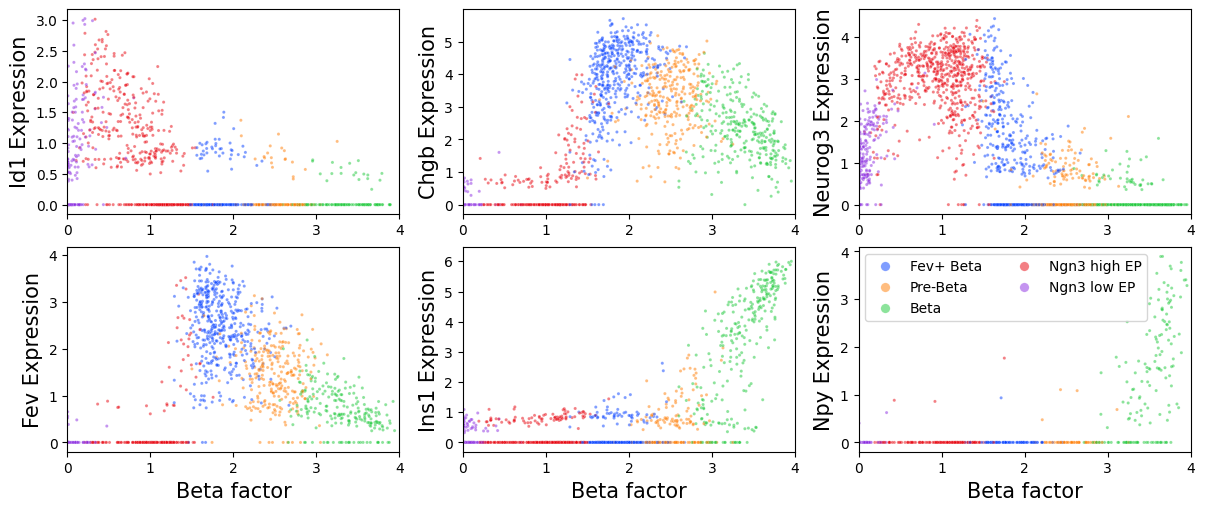

In [110]:

def plot_gene_expression_pseudotime(adata, gene_symbols, pseudotime_column, color_column, zero_frac_to_remove_lst = None, order=None, colns=3, title='', fontsize =  15, x_lim = None, x_label = 'Pseudotime'):
    """
    Plots gene expression vs. pseudotime for a list of genes, with a LOWESS curve (with customizable `frac`) and scatter plot colored by a specified column.
    Displays the plots in a grid format.

    Parameters:
    - adata: AnnData object containing gene expression data in `X` and metadata in `obs`.
    - gene_symbols: List of strings, gene symbols to plot the expression of.
    - pseudotime_column: String, column name in `obs` for pseudotime data.
    - color_column: String, column name in `obs` for color coding the scatter plot.
    - lowess_frac: List of floats, one LOWESS smoothing parameter for each gene in `gene_symbols`.
    - order: List or None, custom ordering of cell labels for coloring the plot. If None, the default order is used.
    - colns: Integer, number of columns in the grid of plots.
    - title: String, optional, overarching title for the grid of plots.
    """
    # Check if all gene_symbols exist in adata.var
    if zero_frac_to_remove_lst is None:
        zero_frac_to_remove_lst = [0.5] * len(gene_symbols)
    missing_genes = [gene for gene in gene_symbols if gene not in adata.var_names]
    if missing_genes:
        raise ValueError(f"Gene symbol(s) {missing_genes} not found in adata.var_names.")
    
    # Check if the number of lowess_frac values matches the number of genes
    if len(zero_frac_to_remove_lst) != len(gene_symbols):
        raise ValueError("The length of `zero_frac_to_remove_lst` must match the length of `gene_symbols`.")
    
    # Calculate the number of rows needed for the grid
    rows = -(-len(gene_symbols) // colns)  # Ceiling division to get number of rows
    
    # Create the grid of subplots
    fig, axes = plt.subplots(rows, colns, figsize=(colns * 4, rows * 2.5), constrained_layout=True)
    axes = axes.flatten()  # Flatten the axes array for easy indexing
    total_subplots = len(gene_symbols)

    # Number of plots in the last row
    last_row_subplots = total_subplots - (total_subplots % colns if total_subplots % colns != 0 else colns)
    # Loop through each gene and create a plot
    for idx, (gene_symbol, zero_frac_to_remove) in enumerate(zip(gene_symbols, zero_frac_to_remove_lst)):
        # Extract gene expression, pseudotime, and color data
        gene_idx = np.where(adata.var_names == gene_symbol)[0][0]
        gene_expression = adata.X[:, gene_idx].toarray().flatten() if hasattr(adata.X, 'toarray') else adata.X[:, gene_idx].flatten()
        pseudotime = adata.obs[pseudotime_column]
        color_data = adata.obs[color_column]
        
        gene_ind  = np.where(((gene_expression!=0) | np.random.binomial(1, 1.0 - zero_frac_to_remove, gene_expression.shape).astype(bool)))[0]
        gene_expression = gene_expression[gene_ind] 
        pseudotime = pseudotime[gene_ind]
        color_data = color_data[gene_ind]

        
        # If order is provided, reorder the color_data accordingly
        if order is not None:
            color_data = pd.Categorical(color_data, categories=order, ordered=True)
            
        # Create a dataframe for plotting
        df = pd.DataFrame({
            'gene_expression': gene_expression,
            'pseudotime': pseudotime,
            'color_data': color_data
        })

        # Plot scatterplot with custom order if specified
        ax = axes[idx]
        sns.scatterplot(
            x='pseudotime', 
            y='gene_expression', 
            hue='color_data', 
            data=df, 
            palette='bright', 
            s=5, 
            hue_order=order, 
            alpha=0.5, 
            ax=ax
        )
        
        # Fit and plot LOWESS curve with the specified smoothing parameter
        # lowess = sm.nonparametric.lowess(df['gene_expression'], df['pseudotime'], frac = 0.2)
        # ax.plot(lowess[:, 0], lowess[:, 1].clip(min = 0), color='black', linewidth=1, label='LOWESS')
        
        # Customize plot
        # ax.set_title(f'{gene_symbol} Expression')
        if idx >= last_row_subplots:
            ax.set_xlabel(x_label, fontsize =fontsize) 
        else:  
            ax.set_xlabel('')
            
        ax.set_ylabel(f'{gene_symbol} Expression', fontsize = fontsize)
        if idx ==(len(gene_symbols)-1) : ax.legend(markerscale = 3.0, ncols = 2)
        else: ax.legend().remove()

        if x_lim: ax.set_xlim(*x_lim)

    # Remove any unused axes if the number of genes < grid size
    for idx in range(len(gene_symbols), len(axes)):
        fig.delaxes(axes[idx])

    # Add an overarching title if provided
    if title:
        fig.suptitle(title, fontsize=16)
    
    plt.show()


adata_norm.obs['beta_factor'] = adata.obsm["X_scVI"][ :, 51]
zero_frac_to_remove_lst = [0.6, 0.8, 0.0, 0.8, 0.6, 0.8] #, 'Arhgap36', 'Sdf2l1', 'Nnat'] 

plot_gene_expression_pseudotime(adata_norm, [ 'Id1', 'Chgb','Neurog3','Fev','Ins1', 'Npy'], 'beta_factor', 'clusters_fine', zero_frac_to_remove_lst =zero_frac_to_remove_lst, order= ['Fev+ Beta', 'Pre-Beta' ,'Beta','Ngn3 high EP', 'Ngn3 low EP'], x_lim =(0.0,4.0), x_label = 'Beta factor')


In [108]:

group1 =  [ 'Ngn3 high EP', 'Fev+ Beta']
de_df = scvi_palava.differential_expression(groupby ='clusters_fine', delta=0.1, group1 =  group1, n_samples = 400, path_index = [ 51,50])#  path_index = [ 51]
markers_1 = {} # Dictionary to save the markers
cats = group1
for c in cats:
    cid = f"{c} vs Rest"
    cell_type_df = de_df.loc[de_df.comparison == cid]

    cell_type_df = cell_type_df[cell_type_df.lfc_mean > 0] 
    cell_type_df = cell_type_df[cell_type_df["bayes_factor"] > 3] 
    cell_type_df = cell_type_df[cell_type_df["non_zeros_proportion1"] > 0.1] 
    cell_type_df = cell_type_df.sort_values(by ='lfc_mean',ascending=False)
    markers_1[c] = cell_type_df.index.tolist()[:15]
print('Marker genes for the different clusters')
print(markers_1)

group1 = ['Pre-Beta', 'Beta']
de_df = scvi_palava.differential_expression(groupby ='clusters_fine', delta=0.05, group1 =  group1, n_samples = 280, path_index = [ 51,50])#  path_index = [ 51]
markers_2 = {} # Dictionary to save the markers
cats = group1
for c in cats:
    cid = f"{c} vs Rest"
    cell_type_df = de_df.loc[de_df.comparison == cid]

    cell_type_df = cell_type_df[cell_type_df.lfc_mean > 0] 
    cell_type_df = cell_type_df[cell_type_df["bayes_factor"] > 3] 
    cell_type_df = cell_type_df[cell_type_df["non_zeros_proportion1"] > 0.1] 
    cell_type_df = cell_type_df.sort_values(by ='lfc_mean',ascending=False)
    markers_2[c] = cell_type_df.index.tolist()[:15]
print('Marker genes for the different clusters')
print(markers_2)
markers = markers_1 | markers_2

#markers['Ngn3 low EP'] = ['KAMP' if gene == '1700011H14Rik' else gene for gene in markers['Ngn3 low EP']]
markers['Pre-Beta'] = ['Sertad4b' if gene == '1700086L19Rik' else gene for gene in markers['Pre-Beta']]
markers['Fev+ Beta'] = ['Sertad4b' if gene == '1700086L19Rik' else gene for gene in markers['Fev+ Beta']]
markers['Fev+ Beta'] = ['EOLA1' if gene == '1110012L19Rik' else gene for gene in markers['Fev+ Beta']]



DE...: 100%|██████████| 2/2 [00:00<00:00,  5.82it/s]
Marker genes for the different clusters
{'Ngn3 high EP': ['Btbd17', 'Gadd45a', 'Ppp1r14a', 'Krtap17-1', 'Id1', 'Cdc14b', 'Smarcd2', 'Grasp', 'Olfm1', 'Ttc28', 'Neurod2', 'Amotl2', 'Rasl11b', 'Tead2', 'Neurog3'], 'Fev+ Beta': ['Chgb', 'Cryba2', 'Cck', 'Hmgn3', 'Pax6', 'Gch1', 'Runx1t1', 'Pcsk1n', 'Etv1', 'Prrg2', '1700086L19Rik', 'BC023829', 'Slc38a5', 'Lrpprc', 'Fev']}
DE...: 100%|██████████| 2/2 [00:00<00:00,  6.04it/s]
Marker genes for the different clusters
{'Pre-Beta': ['Iapp', 'Ins2', 'Chgb', 'Chga', 'Pyy', 'Pcsk1n', 'Pcsk2', 'Nnat', 'Ppp1r1a', '1700086L19Rik', 'Slc38a5', 'Rbp4', 'Ins1', 'Lrpprc', 'Cpe'], 'Beta': ['Ins2', 'Ins1', 'Iapp', 'Npy', 'Nnat', 'Ppp1r1a', 'Pyy', 'Gip', 'Sytl4', 'Prss53', 'Sdf2l1', 'Gng12', 'Scg2', 'Pcsk2', 'Rbp4']}


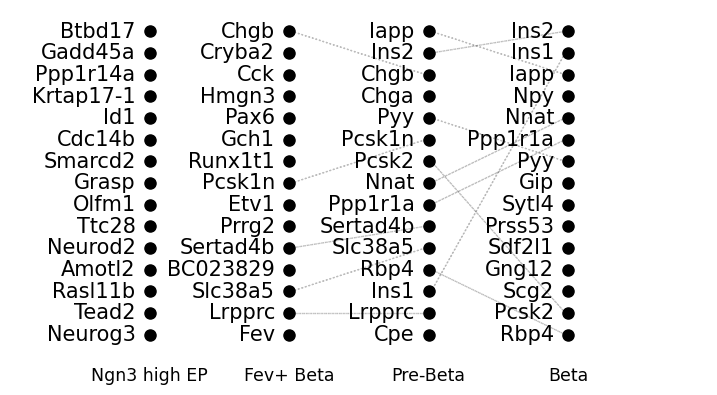

In [109]:

def plot_multiple_ranks(data, colors=None, labels_offset=0.1, arrow_len=0, y_spacing=1, 
                        draw_uncolored_edges=True, title='', show_uncolored_nodes=True, color_legend=None):
    """
    Plots ranked lists with connections and optional coloring and legend.
    
    Parameters:
    - data: dict
        A dictionary where keys are list names and values are ranked lists.
    - colors: dict, optional
        A dictionary mapping items to colors.
    - labels_offset: float, optional
        Horizontal offset for text labels.
    - arrow_len: float, optional
        Arrowhead length for connections.
    - y_spacing: float, optional
        Vertical spacing between nodes.
    - draw_uncolored_edges: bool, optional
        Whether to draw edges for uncolored nodes.
    - title: str, optional
        Title for the plot.
    - show_uncolored_nodes: bool, optional
        Whether to display labels for uncolored nodes.
    - color_legend: dict, optional
        A dictionary mapping colors to legend labels (e.g., {'red': 'Beta', 'green': 'Delta'}).
    """
    import numpy as np  # Import if not already in use
    import matplotlib.patches as mpatches  # For creating legend patches
    
    keys = list(data.keys())  # Extract the keys from the dictionary
    num_lists = len(keys)  # Number of input lists
    fig, ax = plt.subplots(figsize=(9, 4.5))
    
    ax.set_xlim(0, num_lists + 1)  # Adjust x-limits based on the number of lists
    max_len = max(len(lst) for lst in data.values())  # Find the longest list for y-axis limits
    
    # Reverse the order of each list
    reversed_data = {key: lst[::-1] for key, lst in data.items()}

    # Calculate y-values for each reversed list
    y_values = [np.arange(1, len(reversed_data[key]) * y_spacing + 1, y_spacing) for key in keys]
    ax.set_ylim(0, max(len(lst) * y_spacing for lst in reversed_data.values()) + y_spacing)  # Set y-limits
    
    ax.axis('off')  # Remove axes

    # Draw arrows between the lists
    for i in range(num_lists - 1):  # Loop through each adjacent pair of lists
        current_list = reversed_data[keys[i]]
        next_list = reversed_data[keys[i + 1]]
        
        # Create a mapping from current list to next list
        current_to_next = [next_list.index(item) if item in next_list else None for item in current_list]
        
        for j in range(len(current_list)):
            if current_to_next[j] is not None:
                # Determine the color for the edge based on the current node color
                edge_color = colors.get(current_list[j], 'black') if colors else 'black'
                
                # Check if we should skip drawing this edge
                if edge_color == 'black' and not draw_uncolored_edges:
                    continue
                
                # Draw the arrow with the corresponding edge color
                ax.arrow(i + 1.02, y_values[i][j], 
                         0.96, y_values[i + 1][current_to_next[j]] - y_values[i][j], 
                         head_width=arrow_len, head_length=arrow_len, 
                         fc=edge_color, ec=edge_color, length_includes_head=True, linestyle=':', alpha=0.25)

    # Plot points for each reversed list
    for i, key in enumerate(keys):
        lst = reversed_data[key]
        for j in range(len(lst)):
            # Default to black for the points
            ax.plot(i + 1, y_values[i][j], 'o', markersize=8, color='black')  # Points
            
            # Determine the color for each gene, defaulting to black if not found
            text_color = colors.get(lst[j], 'black') if colors else 'black'
            
            # Show the node name only if the color is specified or if show_uncolored_nodes is True
            if text_color != 'black' or show_uncolored_nodes:
                ax.text(i + 1 - labels_offset, y_values[i][j], lst[j], 
                        verticalalignment='center', horizontalalignment='right', color=text_color, fontsize=15)

        # Add key label at the bottom of each column
        ax.text(i + 1, -0.5, key, verticalalignment='top', horizontalalignment='center', fontsize=12.5)

    # Add title
    plt.title(title, fontsize=20)

    # Add legend if color_legend is provided
    if color_legend:
        legend_patches = [mpatches.Patch(color=color, label=label) for color, label in color_legend.items()]
        ax.legend(handles=legend_patches, loc='lower center', fontsize=15, title="Legend", bbox_to_anchor=(0.7, 0., 0.5, 0.5) )
    
    plt.show()
    

plot_multiple_ranks(markers,   draw_uncolored_edges=True,show_uncolored_nodes=True, title = '',labels_offset=0.1)
